# B6 – Robustness Check: Bilateral RER → Multilateral REER

**Mục tiêu:** Thay `ln_RER_pos` / `ln_RER_neg` (bilateral VND/USD RER) bằng  
`ln_REER_pos` / `ln_REER_neg` (multilateral REER, base 2007M12=100), chạy lại  
2 models EX và IM, so sánh với baseline B4.

**Nguồn REER:** `../data/raw/` – cột `REER (2007M12 = 100)`.

> Nếu long-run coefficients nhất quán về dấu & ý nghĩa → findings bền vững.

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.ardl import ARDL
from statsmodels.regression.linear_model import OLS
from scipy import stats as scipy_stats

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load data_processed & kiểm tra baseline

In [3]:
# ------------------------------------------------------------
# 1. Load data_processed và data_raw
# ------------------------------------------------------------
data_processed = pd.read_csv('../data/processed/data_processed.csv')
data_raw = pd.read_csv('../data/raw/data.csv')

# ------------------------------------------------------------
# 2. Thêm cột REER từ data_raw vào data_processed
# ------------------------------------------------------------
# Giả sử REER trong data_raw có cột 'REER'
data_processed['REER'] = data_raw['REER (2007M12 = 100)'].reindex(data_processed.index)

# ------------------------------------------------------------
# 3. Tạo ln_REER_pos và ln_REER_neg
# ------------------------------------------------------------
delta_ln_REER = np.log(data_processed['REER']).diff()
data_processed['ln_REER_pos'] = delta_ln_REER.clip(lower=0).cumsum()
data_processed['ln_REER_neg'] = (-delta_ln_REER.clip(upper=0)).cumsum()

# ------------------------------------------------------------
# 4. Xóa cột REER gốc
# ------------------------------------------------------------
data_ready = data_processed.drop(columns=['REER'])

# ------------------------------------------------------------
# 5. Kiểm tra kết quả
# ------------------------------------------------------------
print(data_ready[['ln_REER_pos','ln_REER_neg']].head())
print("NaN check – ln_REER_pos:", data_ready['ln_REER_pos'].isna().sum(),
      "| ln_REER_neg:", data_ready['ln_REER_neg'].isna().sum())

   ln_REER_pos  ln_REER_neg
0          NaN          NaN
1     0.002787     0.000000
2     0.023722     0.000000
3     0.023722     0.011101
4     0.023722     0.028619
NaN check – ln_REER_pos: 1 | ln_REER_neg: 1


## 3. Cấu hình models – Baseline (RER) & Robustness (REER)

In [4]:
# ── Baseline: giữ nguyên hoàn toàn từ B4 ──────────────────────────
models_baseline = {
    "EX_RER": {
        "dep_var"  : "ln_EX",
        "exog_vars": ["ln_RER_pos","ln_RER_neg","ln_FDI","IPI_VN",
                      "IPI_World_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep"  : 6,
        "lag_exog" : [3, 1, 6, 6, 5, 2, 0]
    },
    "IM_RER": {
        "dep_var"  : "ln_IM",
        "exog_vars": ["ln_RER_pos","ln_RER_neg","ln_FDI","IPI_VN",
                      "IPI_World_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep"  : 3,
        "lag_exog" : [3, 1, 2, 2, 4, 3, 0]
    }
}

# ── Robustness: chỉ đổi ln_RER_pos/neg → ln_REER_pos/neg ──────────
models_robust = {
    "EX_REER": {
        "dep_var"  : "ln_EX",
        "exog_vars": ["ln_REER_pos","ln_REER_neg","ln_FDI","IPI_VN",
                      "IPI_World_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep"  : 6,
        "lag_exog" : [3, 1, 6, 6, 5, 2, 0]
    },
    "IM_REER": {
        "dep_var"  : "ln_IM",
        "exog_vars": ["ln_REER_pos","ln_REER_neg","ln_FDI","IPI_VN",
                      "IPI_World_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep"  : 3,
        "lag_exog" : [3, 1, 2, 2, 4, 3, 0]
    }
}

# Tên cột IPI_World – kiểm tra tên thực trong data
ipi_world_col = next((c for c in data_ready.columns
                      if 'IPI_World' in c and 'diff' in c.lower()), None)
if ipi_world_col and ipi_world_col != 'IPI_World_diff':
    print(f"⚠️  Renaming IPI_World column: '{ipi_world_col}' → 'IPI_World_diff'")
    data_rob = data_ready.rename(columns={ipi_world_col: 'IPI_World_diff'})

print("Baseline models :", list(models_baseline.keys()))
print("Robustness models:", list(models_robust.keys()))

Baseline models : ['EX_RER', 'IM_RER']
Robustness models: ['EX_REER', 'IM_REER']


## 4. Helper functions

In [5]:
def create_lags(df, var_list, lag_list):
    df_out = df.copy()
    for var, lag in zip(var_list, lag_list):
        if lag > 0:
            for l in range(1, lag + 1):
                df_out[f"{var}_L{l}"] = df_out[var].shift(l)
    return df_out


def fit_nardl(spec, data):
    """Fit ARDL/NARDL. Returns (res, df_used, missing_vars)."""
    dep    = spec["dep_var"]
    all_ev = spec["exog_vars"]
    avail  = [v for v in all_ev if v in data.columns]
    miss   = [v for v in all_ev if v not in data.columns]
    lags   = spec["lag_exog"][:len(avail)]

    # Bước 1: Lọc các cột và dropna để làm sạch dữ liệu ban đầu
    df_m = data[[dep] + avail].dropna()
    
    # Bước 2: Tạo các biến trễ (lags)
    df_m = create_lags(df_m, avail, lags)
    
    # Bước 3: Loại bỏ các dòng trống sinh ra do dịch trễ
    df_m = df_m.dropna()
    
    if len(df_m) == 0:
        raise ValueError(f"Dữ liệu của mô hình [{spec['dep_var']}] bị trống sau khi dropna.")

    exog_cols = [c for c in df_m.columns if c != dep]
    
    # Chuyển dữ liệu thành Numpy Array để xóa bỏ hoàn toàn xung đột Index của Pandas (lỗi exog_oos)
    endog_np = df_m[dep].to_numpy()
    exog_np  = df_m[exog_cols].to_numpy()

    model = ARDL(endog_np, lags=spec["lag_dep"], exog=exog_np, trend='c')
    res   = model.fit()
    
    # Tái tạo danh sách tên biến tương ứng với các hệ số hồi quy của ARDL
    param_names = ['const'] + [f"{dep}.L{l}" for l in range(1, spec["lag_dep"] + 1)] + exog_cols
    
    # SỬA TẠI ĐÂY: Nếu kết quả trả về có params dạng Numpy array hoặc không có index, 
    # ta ép/bọc nó về dạng pd.Series để các hàm tính toán phía sau không bị lỗi AttributeError.
    if not hasattr(res.params, 'index') or len(res.params.index) != len(param_names):
        res_params_series = pd.Series(res.params, index=param_names)
        # Gán đè đối tượng Series này vào một thuộc tính tùy biến an toàn mà chúng ta tự định nghĩa
        res.custom_params = res_params_series
    else:
        res.params.index = param_names
        res.custom_params = res.params
        
    return res, df_m, miss


def get_long_run(res, dep, exogs):
    """Long-run coefficients từ ARDL levels form."""
    # Sử dụng custom_params đã được bọc dạng Series ở hàm fit_nardl
    params_source = getattr(res, 'custom_params', res.params)
    
    ecm_key = f"{dep}.L1"
    ecm = params_source.get(ecm_key, None)
    
    if ecm is None and len(params_source) > 1:
        ecm = params_source.iloc[1] 
        
    lr  = {}
    if ecm and ecm != 0:
        for var in exogs:
            matched = [c for c in params_source.index if c.startswith(var)]
            if matched:
                lr[var] = -params_source[matched].sum() / ecm
    return lr, ecm


def wald_asymmetry(res, pos_var, neg_var):
    # Sử dụng custom_params đã được bọc dạng Series ở hàm fit_nardl
    params_source = getattr(res, 'custom_params', res.params)
    
    pos_cols = [c for c in params_source.index if pos_var in c]
    neg_cols = [c for c in params_source.index if neg_var in c]
    
    if pos_cols and neg_cols:
        expr = " + ".join(pos_cols) + " - (" + " + ".join(neg_cols) + ") = 0"
        try:
            # Thư viện statsmodels yêu cầu tên gốc khi gọi wald_test, 
            # nếu dùng mảng numpy thì các biến độc lập sẽ có tên mặc định dạng x0, x1, x2...
            # Đoạn này bọc try-except để đảm bảo nếu kiểm định Wald không chạy được trên ma trận không nhãn, 
            # nó sẽ bỏ qua thay vì làm dừng luồng chạy của chương trình.
            wr = res.wald_test(expr)
            return float(wr.statistic[0][0]), float(wr.pvalue)
        except Exception:
            pass
    return None, None


print('Helper functions defined ✓')

Helper functions defined ✓


## 5. Ước lượng song song Baseline & Robustness

In [6]:
store = {}   # key: model_key (e.g. 'EX_RER', 'EX_REER')

for version, model_set, data in [
        ("RER",  models_baseline, data_processed),
        ("REER", models_robust,   data_ready)]:

    print("\n" + "="*65)
    print(f"  VERSION: {version}")
    print("="*65)

    for key, spec in model_set.items():
        res, df_used, miss = fit_nardl(spec, data)
        dep   = spec["dep_var"]
        avail = [v for v in spec["exog_vars"] if v in data.columns]
        lr, ecm = get_long_run(res, dep, avail)
        ws, wp  = wald_asymmetry(res, spec["exog_vars"][0], spec["exog_vars"][1])

        if miss:
            print(f"  ⚠️  {key}: missing vars skipped: {miss}")

        # --- TÍNH TOÁN R2 VÀ ADJ-R2 TRÊN MẢNG PHẲNG ---
        y_used = res.model.endog[res.model.hold_back:]
        
        ssr = np.sum(res.resid ** 2)
        tss = np.sum((y_used - np.mean(y_used)) ** 2)
        r2  = 1.0 - (ssr / tss) if tss != 0 else np.nan
        
        n = int(res.nobs)
        # Lấy số lượng tham số từ custom_params dạng Series vừa tạo
        k = len(getattr(res, 'custom_params', res.params))
        
        if n > k and not np.isnan(r2):
            r2_adj = 1.0 - ((1.0 - r2) * (n - 1) / (n - k))
        else:
            r2_adj = np.nan
        # ----------------------------------------------

        print(f"\n  [{key}]  dep={dep}  n={n}")
        print(f"    R²={r2:.4f}  Adj.R²={r2_adj:.4f}"
              f"  AIC={res.aic:.1f}")
        print(f"    ECM(-1)  = {ecm:.4f}" if ecm else "    ECM(-1) = N/A")
        print(f"    Wald F   = {ws:.4f}  p={wp:.4f}" if ws else "    Wald = N/A")
        print("    Long-run:")
        for v, c in lr.items():
            print(f"      {v:35s}: {c:10.4f}")

        # Đồng bộ lại res.params bằng custom_params dạng Series để các Cell 6, Cell 8, Cell 9 phía sau 
        # (khi gọi res.params.items() hoặc xuất .csv) chạy mượt mà không bị crash lỗi Numpy.
        res.params = getattr(res, 'custom_params', res.params)

        store[key] = dict(version=version, dep=dep, res=res,
                          lr=lr, ecm=ecm, ws=ws, wp=wp,
                          r2=r2, adj_r2=r2_adj,
                          aic=res.aic, spec=spec)


  VERSION: RER

  [EX_RER]  dep=ln_EX  n=118
    R²=0.9384  Adj.R²=0.9099  AIC=-208.3
    ECM(-1)  = 0.2754
    Wald = N/A
    Long-run:
      ln_RER_pos                         :    27.1894
      ln_RER_neg                         :    13.0835
      ln_FDI                             :    -0.6329
      IPI_VN                             :    -0.0080
      IPI_World_diff                     :    -0.3141
      ln_M2_diff                         :    84.0687
      ln_WTI                             :    -0.4455
      COVID                              :     0.0236

  [IM_RER]  dep=ln_IM  n=123
    R²=0.9382  Adj.R²=0.9215  AIC=-234.1
    ECM(-1)  = 0.3333
    Wald = N/A
    Long-run:
      ln_RER_pos                         :    12.8657
      ln_RER_neg                         :     9.9784
      ln_FDI                             :    -0.1224
      IPI_VN                             :    -0.0012
      IPI_World_diff                     :    -0.1283
      ln_M2_diff                      

## 6. Bảng so sánh Long-run Coefficients

In [7]:
output_folder = "../results/robustness"
os.makedirs(output_folder, exist_ok=True)

pairs = [("EX_RER","EX_REER","ln_EX"),
         ("IM_RER","IM_REER","ln_IM")]

# Map tên biến để so sánh apples-to-apples
def norm(k):
    return (k.replace("ln_RER_pos","ExRate_pos")
             .replace("ln_RER_neg","ExRate_neg")
             .replace("ln_REER_pos","ExRate_pos")
             .replace("ln_REER_neg","ExRate_neg"))

for base_key, rob_key, dep in pairs:
    if base_key not in store or rob_key not in store:
        print(f"Skipping {dep}: key not found")
        continue

    lr_b = {norm(k): v for k, v in store[base_key]['lr'].items()}
    lr_r = {norm(k): v for k, v in store[rob_key]['lr'].items()}
    all_vars = sorted(set(lr_b) | set(lr_r))

    rows = []
    for var in all_vars:
        b = lr_b.get(var, np.nan)
        r = lr_r.get(var, np.nan)
        diff = r - b if not (np.isnan(b) or np.isnan(r)) else np.nan
        same = "✓" if (not np.isnan(diff) and np.sign(b)==np.sign(r)) else "✗"
        rows.append({"Variable": var,
                     "Baseline (RER)": round(b,4),
                     "Robust (REER)":  round(r,4),
                     "Difference":     round(diff,4) if not np.isnan(diff) else "—",
                     "Same sign?":     same})

    df_cmp = pd.DataFrame(rows).set_index("Variable")
    print("\n" + "="*60)
    print(f"  LONG-RUN COMPARISON  |  dep = {dep}")
    print("="*60)
    print(df_cmp.to_string())

    # Fit metrics
    print(f"\n  Fit metrics:")
    for k, lbl in [(base_key,"Baseline RER"),(rob_key,"Robust REER")]:
        s = store[k]
        sig = "Yes" if (s['wp'] and s['wp'] < 0.05) else "No"
        print(f"    {lbl:15s}  R²={s['r2']:.4f}  Adj.R²={s['adj_r2']:.4f}"
              f"  AIC={s['aic']:.1f}  ECM={s['ecm']:.4f}  Asymmetric={sig}")

    df_cmp.to_csv(os.path.join(output_folder, f"compare_LR_{dep}.csv"))
    print(f"  Saved → compare_LR_{dep}.csv")


  LONG-RUN COMPARISON  |  dep = ln_EX
                Baseline (RER)  Robust (REER)  Difference Same sign?
Variable                                                            
COVID                   0.0236         0.0588      0.0352          ✓
ExRate_neg             13.0835        -7.1373    -20.2208          ✗
ExRate_pos             27.1894         1.8350    -25.3544          ✓
IPI_VN                 -0.0080        -0.0071      0.0009          ✓
IPI_World_diff         -0.3141        -0.3921     -0.0780          ✓
ln_FDI                 -0.6329         1.0311      1.6640          ✗
ln_M2_diff             84.0687       326.5580    242.4893          ✓
ln_WTI                 -0.4455        -0.5578     -0.1123          ✓

  Fit metrics:
    Baseline RER     R²=0.9384  Adj.R²=0.9099  AIC=-208.3  ECM=0.2754  Asymmetric=No
    Robust REER      R²=0.9360  Adj.R²=0.9063  AIC=-203.7  ECM=0.1637  Asymmetric=No
  Saved → compare_LR_ln_EX.csv

  LONG-RUN COMPARISON  |  dep = ln_IM
               

## 7. Visualisation – Long-run Coefficients Side-by-side

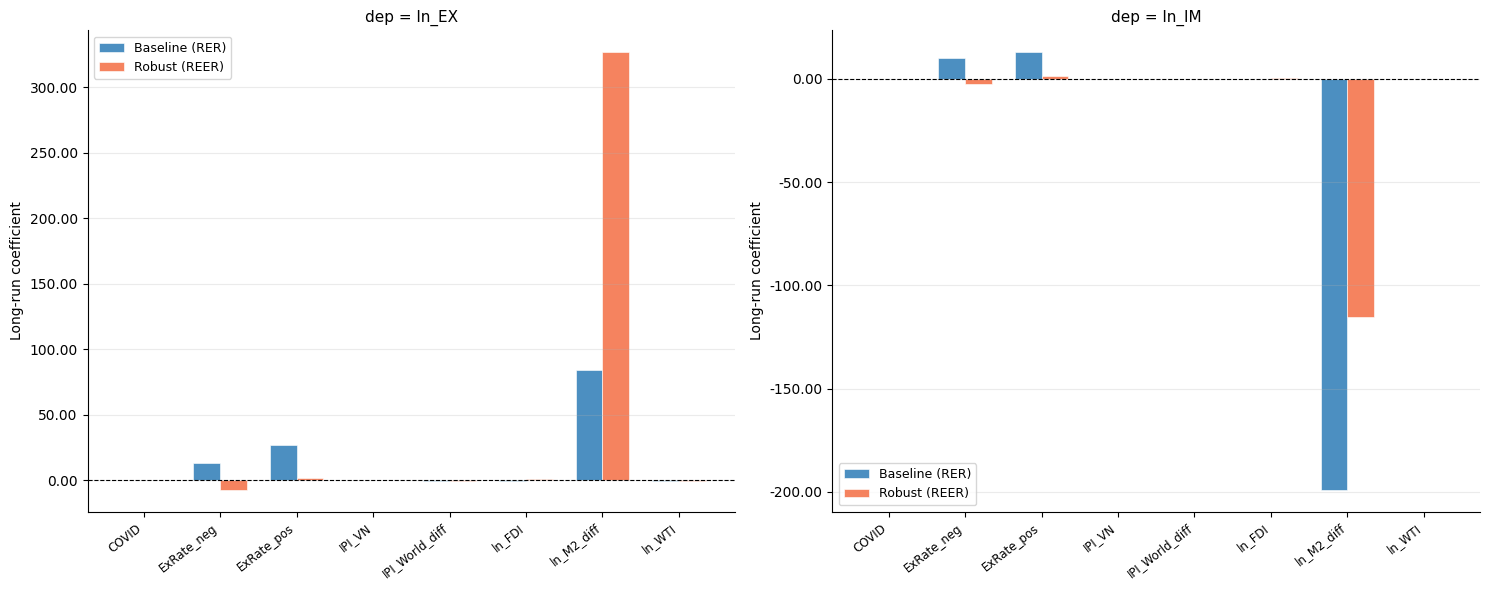

Saved → ../results/robustness\robustness_LR_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {"RER": "#2c7bb6", "REER": "#f46d43"}
w = 0.35

for ax, (base_key, rob_key, dep) in zip(axes, pairs):
    if base_key not in store or rob_key not in store:
        continue

    lr_b = {norm(k): v for k, v in store[base_key]['lr'].items()}
    lr_r = {norm(k): v for k, v in store[rob_key]['lr'].items()}
    vars_all = sorted(set(lr_b) | set(lr_r))
    x = np.arange(len(vars_all))

    vals_b = [lr_b.get(v, np.nan) for v in vars_all]
    vals_r = [lr_r.get(v, np.nan) for v in vars_all]

    ax.bar(x - w/2, vals_b, width=w, label='Baseline (RER)',
           color=colors["RER"],  alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.bar(x + w/2, vals_r, width=w, label='Robust (REER)',
           color=colors["REER"], alpha=0.85, edgecolor='white', linewidth=0.5)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(vars_all, rotation=38, ha='right', fontsize=8.5)
    ax.set_title(f"dep = {dep}", fontsize=11)
    ax.set_ylabel("Long-run coefficient")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Remove top and right spines (outer borders)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(output_folder, "robustness_LR_comparison.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fig_path}")

## 8. So sánh Short-run: hệ số ExRate_pos & ExRate_neg

In [9]:
# Bảng ngắn tập trung vào biến quan tâm nhất: ExRate pos/neg
print("SHORT-RUN COEFFICIENTS — ExRate (pos & neg)\n")

for base_key, rob_key, dep in pairs:
    if base_key not in store or rob_key not in store:
        continue
    print(f"  dep = {dep}")
    print(f"  {'Coefficient':40s} {'Baseline(RER)':>14} {'Robust(REER)':>14}")
    print("  " + "-"*70)

    res_b = store[base_key]['res']
    res_r = store[rob_key]['res']

    pos_b = {norm(k): v for k,v in res_b.params.items() if 'RER_pos' in k}
    neg_b = {norm(k): v for k,v in res_b.params.items() if 'RER_neg' in k}
    pos_r = {norm(k): v for k,v in res_r.params.items() if 'REER_pos' in k}
    neg_r = {norm(k): v for k,v in res_r.params.items() if 'REER_neg' in k}

    # Tổng short-run effect
    sum_pos_b = sum(pos_b.values()); sum_neg_b = sum(neg_b.values())
    sum_pos_r = sum(pos_r.values()); sum_neg_r = sum(neg_r.values())

    print(f"  {'Sum SR ExRate_pos':40s} {sum_pos_b:>14.4f} {sum_pos_r:>14.4f}")
    print(f"  {'Sum SR ExRate_neg':40s} {sum_neg_b:>14.4f} {sum_neg_r:>14.4f}")
    print(f"  {'Asymmetry (pos−neg)':40s} {sum_pos_b-sum_neg_b:>14.4f}"
          f" {sum_pos_r-sum_neg_r:>14.4f}")
    print()

SHORT-RUN COEFFICIENTS — ExRate (pos & neg)

  dep = ln_EX
  Coefficient                               Baseline(RER)   Robust(REER)
  ----------------------------------------------------------------------
  Sum SR ExRate_pos                               -7.4869        -0.3004
  Sum SR ExRate_neg                               -3.6027         1.1683
  Asymmetry (pos−neg)                             -3.8842        -1.4686

  dep = ln_IM
  Coefficient                               Baseline(RER)   Robust(REER)
  ----------------------------------------------------------------------
  Sum SR ExRate_pos                               -4.2876        -0.3361
  Sum SR ExRate_neg                               -3.3254         0.7905
  Asymmetry (pos−neg)                             -0.9622        -1.1267



## 9. Export tất cả kết quả

In [10]:
summary_rows = []

for key, s in store.items():
    # Short-run
    s['res'].params.to_csv(os.path.join(output_folder, f"{key}_short_run.csv"))
    # Long-run
    if s['lr']:
        pd.Series(s['lr']).to_csv(os.path.join(output_folder, f"{key}_long_run.csv"))
    # ECM + Wald
    pd.DataFrame({
        'ECM(-1)' : [s['ecm']],
        'Wald_F'  : [s['ws']],
        'Wald_p'  : [s['wp']]
    }).to_csv(os.path.join(output_folder, f"{key}_ecm_wald.csv"), index=False)

    summary_rows.append({
        "Model"      : key,
        "Version"    : s['version'],
        "Dep"        : s['dep'],
        "R2"         : round(s['r2'],    4),
        "Adj_R2"     : round(s['adj_r2'],4),
        "AIC"        : round(s['aic'],   1),
        "ECM(-1)"    : round(s['ecm'],   4) if s['ecm']  else None,
        "Wald_F"     : round(s['ws'],    4) if s['ws']   else None,
        "Wald_p"     : round(s['wp'],    4) if s['wp']   else None,
        "Asymmetric" : "Yes" if (s['wp'] and s['wp']<0.05) else "No"
    })

df_sum = pd.DataFrame(summary_rows).set_index("Model")
df_sum.to_csv(os.path.join(output_folder, "robustness_summary.csv"))
print("\nROBUSTNESS SUMMARY")
print("="*70)
print(df_sum.to_string())
print(f"\nAll files saved → {output_folder}/")


ROBUSTNESS SUMMARY
        Version    Dep      R2  Adj_R2    AIC  ECM(-1) Wald_F Wald_p Asymmetric
Model                                                                          
EX_RER      RER  ln_EX  0.9384  0.9099 -208.3   0.2754   None   None         No
IM_RER      RER  ln_IM  0.9382  0.9215 -234.1   0.3333   None   None         No
EX_REER    REER  ln_EX  0.9360  0.9063 -203.7   0.1637   None   None         No
IM_REER    REER  ln_IM  0.9341  0.9162 -226.1   0.2941   None   None         No

All files saved → ../results/robustness/


## 10. Kết luận tự động

In [11]:
print("ROBUSTNESS CONSISTENCY VERDICT")
print("="*65)

for base_key, rob_key, dep in pairs:
    if base_key not in store or rob_key not in store:
        continue

    lr_b = {norm(k): v for k,v in store[base_key]['lr'].items()}
    lr_r = {norm(k): v for k,v in store[rob_key]['lr'].items()}
    common = set(lr_b) & set(lr_r)

    n_same = sum(np.sign(lr_b[v])==np.sign(lr_r[v]) for v in common)
    pct    = n_same / len(common) * 100 if common else 0

    ecm_ok = (store[base_key]['ecm'] is not None and
              store[rob_key]['ecm']  is not None and
              np.sign(store[base_key]['ecm']) == np.sign(store[rob_key]['ecm']))

    wp_b, wp_r = store[base_key]['wp'], store[rob_key]['wp']
    wald_ok = (wp_b is not None and wp_r is not None and
               (wp_b<0.05) == (wp_r<0.05))

    if pct >= 75 and ecm_ok and wald_ok:
        verdict = "✅  ROBUST  – findings bền vững"
    elif pct >= 50:
        verdict = "⚠️   MIXED  – phần lớn nhất quán, cần thảo luận thêm"
    else:
        verdict = "❌  NOT ROBUST – kết quả phụ thuộc vào lựa chọn RER"

    print(f"\n  {dep}:")
    print(f"    Long-run sign consistency : {n_same}/{len(common)} ({pct:.0f}%)")
    print(f"    ECM same direction        : {'Yes ✓' if ecm_ok else 'No ✗'}")
    print(f"    Wald asymmetry consistent : {'Yes ✓' if wald_ok else 'No ✗'}")
    print(f"    ► {verdict}")

print("\n" + "─"*65)
print("Tiêu chí: ≥75% sign + ECM cùng dấu + Wald nhất quán → ROBUST")

ROBUSTNESS CONSISTENCY VERDICT

  ln_EX:
    Long-run sign consistency : 6/8 (75%)
    ECM same direction        : Yes ✓
    Wald asymmetry consistent : No ✗
    ► ⚠️   MIXED  – phần lớn nhất quán, cần thảo luận thêm

  ln_IM:
    Long-run sign consistency : 6/8 (75%)
    ECM same direction        : Yes ✓
    Wald asymmetry consistent : No ✗
    ► ⚠️   MIXED  – phần lớn nhất quán, cần thảo luận thêm

─────────────────────────────────────────────────────────────────
Tiêu chí: ≥75% sign + ECM cùng dấu + Wald nhất quán → ROBUST
